In [1]:
import pandas as pd
import numpy as np

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv("C:/Users/hp/Downloads/pima-indians-diabetes.data.csv",names=columns) 

print("Shape of dataset:", df.shape)          
print("\nColumn Names:\n", df.columns)       
print("\nData Info:\n")
print(df.info())                            
print("\nSummary Statistics:\n", df.describe())  
print("\nFirst 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())

Shape of dataset: (768, 9)

Column Names:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Summary Statistic

In [2]:
#missing values are encoded as 0 
missing_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print("\nNumber of missing values (encoded as 0) per column:")
for col in missing_cols:
    print(f"{col}: {(df[col]==0).sum()}")

for col in missing_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

print("\nAfter replacing 0s with median:")
for col in missing_cols:
    print(f"{col}: {(df[col]==0).sum()}")


Number of missing values (encoded as 0) per column:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11

After replacing 0s with median:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [3]:
print("\nAny remaining missing values per column:\n", df.isnull().sum)
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# Drop duplicates, keep first occurrence
df = df.drop_duplicates(keep='first')
print(df)
print("Shape after removing duplicates:", df.shape)


Any remaining missing values per column:
 <bound method DataFrame.sum of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunc

In [4]:
import pandas as pd

data = {'Age': ['25', '30', '45'], 'Salary': [50000, 60000, 75000]}
df = pd.DataFrame(data)
print("Original dtypes:\n", df.dtypes)

df['Age'] = df['Age'].astype(int)

df['Salary'] = df['Salary'].astype(float)

df['Age_str'] = df['Age'].astype(str)

print("\nAfter Conversion dtypes:\n", df.dtypes)
print("\nDataFrame:\n", df)

Original dtypes:
 Age       object
Salary     int64
dtype: object

After Conversion dtypes:
 Age          int64
Salary     float64
Age_str     object
dtype: object

DataFrame:
    Age   Salary Age_str
0   25  50000.0      25
1   30  60000.0      30
2   45  75000.0      45


Outliers:    Scores
5     100


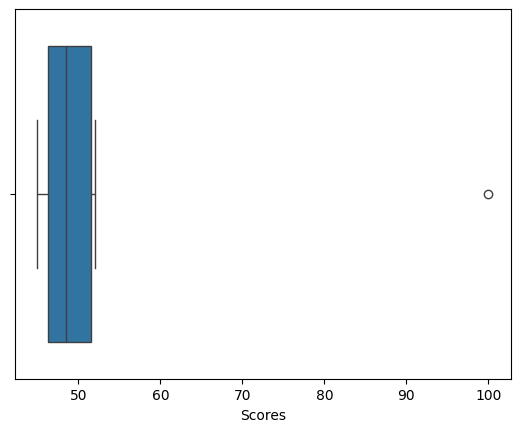

In [5]:
#IQR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {'Scores': [45, 47, 46, 50, 52, 100]}
df = pd.DataFrame(data)

Q1 = df['Scores'].quantile(0.25)
Q3 = df['Scores'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['Scores'] < lower_limit) | (df['Scores'] > upper_limit)]
print("Outliers:", outliers)

sns.boxplot(x=df['Scores'])
plt.show()

In [6]:
#Z score:  z=x−μ/σ
import numpy as np
import pandas as pd
from scipy import stats

heights = [150, 155, 160, 165, 170, 172, 400]
z_scores = np.abs(stats.zscore(heights))

for value, z in zip(heights, z_scores): #specify height with z score
    print(f"Value: {value}, Z-score: {z:.2f}")

df = pd.DataFrame({'Heights': heights, 'Zscore': z_scores})
outliers = df[df['Zscore'] > 3]
print("Outliers using Z-score:", outliers)

Value: 150, Z-score: 0.55
Value: 155, Z-score: 0.49
Value: 160, Z-score: 0.43
Value: 165, Z-score: 0.37
Value: 170, Z-score: 0.31
Value: 172, Z-score: 0.29
Value: 400, Z-score: 2.44
Outliers using Z-score: Empty DataFrame
Columns: [Heights, Zscore]
Index: []


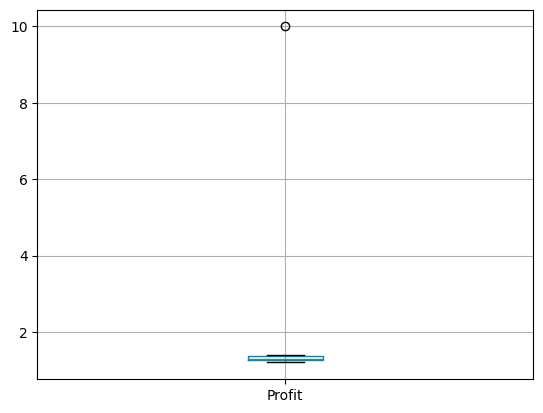

Outliers by IQR:
    Profit
4    10.0
Value: 1.2, Z-score: 0.44
Value: 1.3, Z-score: 0.41
Value: 1.25, Z-score: 0.42
Value: 1.4, Z-score: 0.37
Value: 10.0, Z-score: 2.45
Value: 1.35, Z-score: 0.39
Value: 1.28, Z-score: 0.41
Outliers by Z-score:
 Empty DataFrame
Columns: [Profit, Zscore]
Index: []


In [7]:
import pandas as pd
import numpy as np
profits = [1.2, 1.3, 1.25, 1.4, 10.0, 1.35, 1.28]
df = pd.DataFrame(profits, columns=["Profit"])

# Boxplot
df.boxplot(column="Profit")
plt.show()

# IQR method
Q1, Q3 = df["Profit"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

iqr_outliers = df[(df["Profit"] < lower) | (df["Profit"] > upper)]
print("Outliers by IQR:\n", iqr_outliers)

# Z-score method
z_scores = np.abs(stats.zscore(df["Profit"]))

for value, z in zip(profits, z_scores): #specify height with z score
    print(f"Value: {value}, Z-score: {z:.2f}")

df = pd.DataFrame({'Profit': profits, 'Zscore': z_scores})

z_outliers = df[z_scores > 3]
print("Outliers by Z-score:\n", z_outliers)

Outliers:
    Size
4  5000

After log transformation:
    Size  Log_Size
0  1200  7.090077
1  1300  7.170120
2  1250  7.130899
3  1280  7.154615
4  5000  8.517193


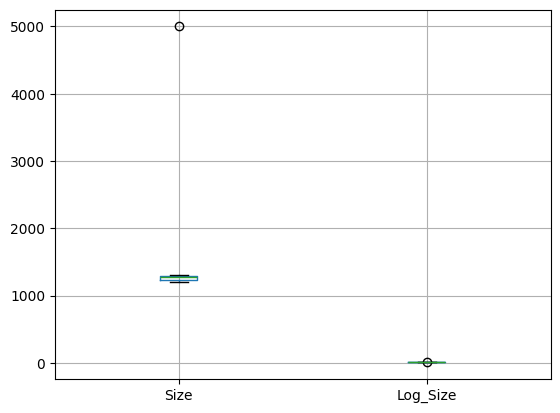

In [8]:
sizes = [1200, 1300, 1250, 1280, 5000, 1220, 1270]
df = pd.DataFrame(sizes, columns=["Size"])

Q1, Q3 = df["Size"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = df[(df["Size"] < lower) | (df["Size"] > upper)]
print("Outliers:\n", outliers)

# Log transformation
df["Log_Size"] = np.log(df["Size"])
print("\nAfter log transformation:\n", df.head())

df[["Size","Log_Size"]].boxplot()
plt.show()

In [9]:
steps = [8000, 8500, 7900, 8100, 8200, 30000, 8300, 8000]
df = pd.DataFrame(steps, columns=["Steps"])

Q1, Q3 = df["Steps"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = df[(df["Steps"] < lower) | (df["Steps"] > upper)]
print("Outliers:\n", outliers)

# Replace with median #.loc is used to access or modify rows and columns by labels
df.loc[outliers.index, "Steps"] = df["Steps"].median()
print("\nAfter replacing with median:\n", df)

new_outliers = df[(df["Steps"] < lower) | (df["Steps"] > upper)]
print("Remaining outliers:", new_outliers)

Outliers:
    Steps
5  30000

After replacing with median:
    Steps
0   8000
1   8500
2   7900
3   8100
4   8200
5   8150
6   8300
7   8000
Remaining outliers: Empty DataFrame
Columns: [Steps]
Index: []


In [10]:
np.random.seed(0)
data = np.random.normal(100, 10, 300).tolist() + [250, 300] #Converts the NumPy array into a Python list.# add two extreme values to the list
df = pd.DataFrame(data, columns=["Value"])

# IQR method
Q1, Q3 = df["Value"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
iqr_outliers = df[(df["Value"] < lower) | (df["Value"] > upper)]

# Z-score method
z_scores = np.abs(stats.zscore(df["Value"]))
z_outliers = df[z_scores > 3]

print("IQR Outliers detected:", len(iqr_outliers))
print("Z-score Outliers detected:", len(z_outliers))

IQR Outliers detected: 3
Z-score Outliers detected: 2


Z-score outliers:
 Empty DataFrame
Columns: [Score]
Index: []

IQR outliers:
    Score
7    150


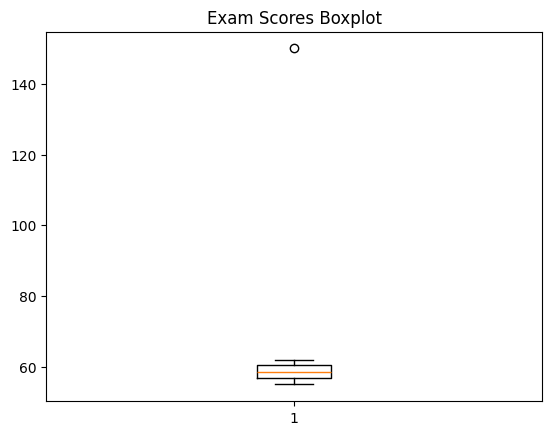

In [11]:
#TASK 1

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

scores = [55, 60, 58, 62, 59, 57, 56, 150]
df = pd.DataFrame(scores, columns=["Score"])

# Z-score method
z_scores = np.abs(stats.zscore(df["Score"]))
print("Z-score outliers:\n", df[z_scores > 3])

# IQR method
Q1, Q3 = df["Score"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
print("\nIQR outliers:\n", df[(df["Score"] < lower) | (df["Score"] > upper)])

# Boxplot
plt.boxplot(df["Score"])
plt.title("Exam Scores Boxplot")
plt.show()

In [12]:
#Handling outliers :removing
import pandas as pd
import numpy as np

data = [55, 60, 58, 62, 59, 57, 56, 150]
df = pd.DataFrame(data, columns=["Score"])

# IQR method
Q1, Q3 = df["Score"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

# Remove outliers
df_removed = df[(df["Score"] >= lower) & (df["Score"] <= upper)]
print("After removing outliers:\n", df_removed)


After removing outliers:
    Score
0     55
1     60
2     58
3     62
4     59
5     57
6     56


In [13]:
#Capping
df_capped = df.copy()
# np.where(condition, value_if_true, value_if_false) : 
df_capped["Score"] = np.where(df_capped["Score"] < lower, lower,
                              np.where(df_capped["Score"] > upper, upper, df_capped["Score"]))

print("After capping outliers:\n", df_capped)

After capping outliers:
     Score
0  55.000
1  60.000
2  58.000
3  62.000
4  59.000
5  57.000
6  56.000
7  66.125


In [14]:
#Transformation
# Log transformation
df["Log_Score"] = np.log(df["Score"])

print("After log transformation:\n", df)

After log transformation:
    Score  Log_Score
0     55   4.007333
1     60   4.094345
2     58   4.060443
3     62   4.127134
4     59   4.077537
5     57   4.043051
6     56   4.025352
7    150   5.010635


In [15]:
rents = [12000, 12500, 12300, 12400, 50000, 12200]
df = pd.DataFrame(rents, columns=["Rent"])

Q1, Q3 = df["Rent"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

df_capped = df.copy()
df_capped["Rent"] = np.where(df_capped["Rent"] > upper, upper,
                             np.where(df_capped["Rent"] < lower, lower, df_capped["Rent"]))

print("After capping:\n", df_capped)

After capping:
       Rent
0  12000.0
1  12500.0
2  12300.0
3  12400.0
4  12850.0
5  12200.0


In [16]:
expenses = [2000, 2100, 1950, 2020, 10000, 1980]
df = pd.DataFrame(expenses, columns=["Expense"])

# IQR method
Q1, Q3 = df["Expense"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

# 1. Removal
df_removed = df[(df["Expense"] >= lower) & (df["Expense"] <= upper)]

# 2. Capping
df_capped = df.copy()
df_capped["Expense"] = np.where(df["Expense"] > upper, upper,
                                np.where(df["Expense"]< lower, lower, df["Expense"]))

# 3. Transformation (Log)
df["Log_Expense"] = np.log(df["Expense"])

print("Removed:\n", df_removed)
print("\nCapped:\n", df_capped)
print("\nLog Transformed:\n", df)

Removed:
    Expense
0     2000
1     2100
2     1950
3     2020
5     1980

Capped:
    Expense
0   2000.0
1   2100.0
2   1950.0
3   2020.0
4   2222.5
5   1980.0

Log Transformed:
    Expense  Log_Expense
0     2000     7.600902
1     2100     7.649693
2     1950     7.575585
3     2020     7.610853
4    10000     9.210340
5     1980     7.590852


In [17]:
ratings = [1, 2, 5, 4, 6, 7, 3, 5]
df = pd.DataFrame(ratings, columns=["Rating"])

# Removal
df_removed = df[(df["Rating"] >= 1) & (df["Rating"] <= 5)]

# Capping
df_capped = df.copy()
df_capped["Rating"] = df_capped["Rating"].clip(lower=1, upper=5)

print("After removal:\n", df_removed)
print("\nAfter capping:\n", df_capped)

After removal:
    Rating
0       1
1       2
2       5
3       4
6       3
7       5

After capping:
    Rating
0       1
1       2
2       5
3       4
4       5
5       5
6       3
7       5


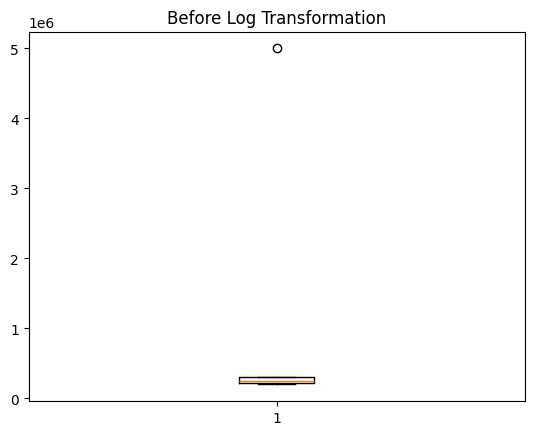

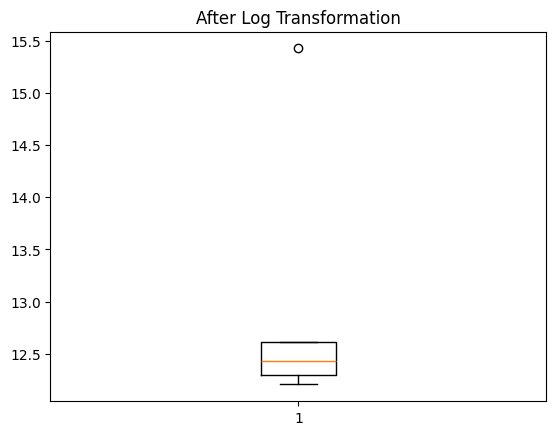

In [18]:
#TASK 2:
import matplotlib.pyplot as plt

prices = pd.DataFrame({'Price': [200000, 220000, 250000, 300000, 5000000]})  # 5M outlier

# Before transformation
plt.boxplot(prices['Price'])
plt.title("Before Log Transformation")
plt.show()

# Log transform
prices['Log_Price'] = np.log(prices['Price'])

# After transformation
plt.boxplot(prices['Log_Price'])
plt.title("After Log Transformation")
plt.show()

In [19]:
#TASK 3:
import pandas as pd
import numpy as np

# Sample dataset with invalid ratings
ratings = pd.DataFrame({'Rating': [5, 4, 3, 0, 2, 6, 7, 1, 5, -1]})
print("Original Ratings:\n", ratings)

# Capping
ratings['Rating_Capped'] = np.where(ratings['Rating'] < 1, 1, ratings['Rating'])
ratings['Rating_Capped'] = np.where(ratings['Rating_Capped'] > 5, 5, ratings['Rating_Capped'])

print("\nRatings after Capping:\n", ratings)

Original Ratings:
    Rating
0       5
1       4
2       3
3       0
4       2
5       6
6       7
7       1
8       5
9      -1

Ratings after Capping:
    Rating  Rating_Capped
0       5              5
1       4              4
2       3              3
3       0              1
4       2              2
5       6              5
6       7              5
7       1              1
8       5              5
9      -1              1


In [20]:
#Min-Max
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Dataset
data = pd.DataFrame({'Marks': [30, 50, 80, 100]})
print("Original Data:\n", data)

# Min-Max Scaling
scaler = MinMaxScaler()
data['Marks_Scaled'] = scaler.fit_transform(data[['Marks']])

print("\nAfter Min-Max Scaling (0-1):\n", data)

Original Data:
    Marks
0     30
1     50
2     80
3    100

After Min-Max Scaling (0-1):
    Marks  Marks_Scaled
0     30      0.000000
1     50      0.285714
2     80      0.714286
3    100      1.000000


In [21]:
#Z score
from sklearn.preprocessing import StandardScaler

# Dataset
data2 = pd.DataFrame({'Height': [150, 160, 170, 180, 190]})
print("Original Data:\n", data2)

# Z-score Standardization
scaler = StandardScaler()
data2['Height_Standardized'] = scaler.fit_transform(data2[['Height']])

print("\nAfter Z-score Standardization:\n", data2)

Original Data:
    Height
0     150
1     160
2     170
3     180
4     190

After Z-score Standardization:
    Height  Height_Standardized
0     150            -1.414214
1     160            -0.707107
2     170             0.000000
3     180             0.707107
4     190             1.414214


In [22]:
#Label encoding
from sklearn.preprocessing import LabelEncoder

# Dataset
df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red']})
print("Original Data:\n", df)

# Label Encoding
le = LabelEncoder()
df['Color_Label'] = le.fit_transform(df['Color'])

print("\nAfter Label Encoding:\n", df)

Original Data:
    Color
0    Red
1   Blue
2  Green
3   Blue
4    Red

After Label Encoding:
    Color  Color_Label
0    Red            2
1   Blue            0
2  Green            1
3   Blue            0
4    Red            2


In [23]:
# One encoding
df2 = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red']})
print("Original Data:\n", df2)

df_onehot = pd.get_dummies(df2, columns=['Color'], prefix='Color')

print("\nAfter One-Hot Encoding:\n", df_onehot)

Original Data:
    Color
0    Red
1   Blue
2  Green
3   Blue
4    Red

After One-Hot Encoding:
    Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3        True        False      False
4       False        False       True


In [24]:
#Orginal encoding
# Dataset
df3 = pd.DataFrame({'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small']})
print("Original Data:\n", df3)

# Ordinal Mapping
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3}
df3['Size_Ordinal'] = df3['Size'].map(size_mapping)

print("\nAfter Ordinal Encoding:\n", df3)


Original Data:
      Size
0   Small
1  Medium
2   Large
3  Medium
4   Small

After Ordinal Encoding:
      Size  Size_Ordinal
0   Small             1
1  Medium             2
2   Large             3
3  Medium             2
4   Small             1


In [25]:
#TASK 4:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 45, 35, 29, 50],
    'Salary': [30000, 80000, 50000, 40000, 100000],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'Finance'],
    'Education': ['Bachelor', 'Master', 'High School', 'Bachelor', 'PhD']
}

df = pd.DataFrame(data)
print("Original Data:\n", df)

# 1. Min-Max Scaling for Salary
scaler_minmax = MinMaxScaler()
df['Salary_Scaled'] = scaler_minmax.fit_transform(df[['Salary']])

# 2. Z-score Standardization for Age
scaler_zscore = StandardScaler()
df['Age_Standardized'] = scaler_zscore.fit_transform(df[['Age']])

# 3. One-Hot Encoding for Department
df = pd.get_dummies(df, columns=['Department'], prefix='Dept')

# 4. Ordinal Encoding for Education
edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df['Education_Ordinal'] = df['Education'].map(edu_map)

print("\nAfter Scaling & Encoding:\n", df)

Original Data:
       Name  Age  Salary Department    Education
0    Alice   25   30000         HR     Bachelor
1      Bob   45   80000         IT       Master
2  Charlie   35   50000    Finance  High School
3    David   29   40000         IT     Bachelor
4      Eve   50  100000    Finance          PhD

After Scaling & Encoding:
       Name  Age  Salary    Education  Salary_Scaled  Age_Standardized  \
0    Alice   25   30000     Bachelor       0.000000         -1.251079   
1      Bob   45   80000       Master       0.714286          0.869394   
2  Charlie   35   50000  High School       0.285714         -0.190843   
3    David   29   40000     Bachelor       0.142857         -0.826984   
4      Eve   50  100000          PhD       1.000000          1.399512   

   Dept_Finance  Dept_HR  Dept_IT  Education_Ordinal  
0         False     True    False                  2  
1         False    False     True                  3  
2          True    False    False                  1  
3        

In [26]:
#TASK 5:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder

# Dataset
data = {
    "Name": ["John", "Alice", "Bob", "David", "Eva"],
    "Age": [18, 19, 20, 18, 21],
    "Marks": [45, 67, 89, 32, 56],
    "Grade": ["C", "B", "A", "D", "B"],
    "Gender": ["Male", "Female", "Male", "Male", "Female"]
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

# 1. Min-Max scaling on Marks
scaler = MinMaxScaler()
df["Marks_MinMax"] = scaler.fit_transform(df[["Marks"]])

# 2. Z-score standardization on Age
scaler = StandardScaler()
df["Age_Zscore"] = scaler.fit_transform(df[["Age"]])

# 3. Label Encoding on Gender
label_encoder = LabelEncoder()
df["Gender_Label"] = label_encoder.fit_transform(df["Gender"])

# 4. Ordinal Encoding on Grade
grade_order = [["D", "C", "B", "A"]]
ordinal_encoder = OrdinalEncoder(categories=grade_order)
df["Grade_Ordinal"] = ordinal_encoder.fit_transform(df[["Grade"]])

# 5. One-Hot Encoding on Gender
onehot_encoder = OneHotEncoder(sparse_output=False, drop="first")  # updated for new sklearn
gender_encoded = onehot_encoder.fit_transform(df[["Gender"]])
df[["Gender_Female"]] = gender_encoded

print("\nTransformed Data:\n", df)

Original Data:
     Name  Age  Marks Grade  Gender
0   John   18     45     C    Male
1  Alice   19     67     B  Female
2    Bob   20     89     A    Male
3  David   18     32     D    Male
4    Eva   21     56     B  Female

Transformed Data:
     Name  Age  Marks Grade  Gender  Marks_MinMax  Age_Zscore  Gender_Label  \
0   John   18     45     C    Male      0.228070   -1.028992             1   
1  Alice   19     67     B  Female      0.614035   -0.171499             0   
2    Bob   20     89     A    Male      1.000000    0.685994             1   
3  David   18     32     D    Male      0.000000   -1.028992             1   
4    Eva   21     56     B  Female      0.421053    1.543487             0   

   Grade_Ordinal  Gender_Female  
0            1.0            1.0  
1            2.0            0.0  
2            3.0            1.0  
3            0.0            1.0  
4            2.0            0.0  


In [27]:
#J,M,C
import pandas as pd

df1 = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['A', 'B', 'C']})
df2 = pd.DataFrame({'ID': [4, 5], 'Name': ['D', 'E']})

df_vertical = pd.concat([df1, df2])
print("Vertical Concatenation:\n", df_vertical)

df_horizontal = pd.concat([df1, df2], axis=1)
print("\nHorizontal Concatenation:\n", df_horizontal)

Vertical Concatenation:
    ID Name
0   1    A
1   2    B
2   3    C
0   4    D
1   5    E

Horizontal Concatenation:
    ID Name   ID Name
0   1    A  4.0    D
1   2    B  5.0    E
2   3    C  NaN  NaN


In [28]:
df_left = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['A', 'B', 'C']})
df_right = pd.DataFrame({'ID': [2, 3, 4], 'Score': [85, 90, 75]})

df_inner = pd.merge(df_left, df_right, on='ID', how='inner') #Only common rows (intersection).
print("Inner Join:\n", df_inner)

df_left_join = pd.merge(df_left, df_right, on='ID', how='left') #All rows from left + matches from right.
print("\nLeft Join:\n", df_left_join)

df_outer = pd.merge(df_left, df_right, on='ID', how='outer') #All rows from both (union).
print("\nOuter Join:\n", df_outer)

Inner Join:
    ID Name  Score
0   2    B     85
1   3    C     90

Left Join:
    ID Name  Score
0   1    A    NaN
1   2    B   85.0
2   3    C   90.0

Outer Join:
    ID Name  Score
0   1    A    NaN
1   2    B   85.0
2   3    C   90.0
3   4  NaN   75.0


In [29]:
import pandas as pd

# Sample dataset
data = pd.DataFrame({
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance'],
    'Employee': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Salary': [40000, 45000, 50000, 55000, 60000, 65000],
    'Bonus': [2000, 2500, 3000, 3500, 4000, 4500]
})

print("Original Data:\n", data, "\n")

# 1. Basic Pivot Table: Average Salary by Department
pivot1 = data.pivot_table(index='Department', values='Salary', aggfunc='mean')
print("Average Salary by Department:\n", pivot1, "\n")

# 2. Multiple Aggregations: Salary and Bonus by Department
pivot2 = data.pivot_table(index='Department', values=['Salary', 'Bonus'], aggfunc='sum')
print("Total Salary & Bonus by Department:\n", pivot2, "\n")

# 3. Pivot with Multiple Indexes
pivot3 = data.pivot_table(index=['Department', 'Employee'], values='Salary', aggfunc='max')
print("Salary per Employee (multi-index):\n", pivot3, "\n")

# 4. Pivot with Multiple Aggregations
pivot4 = data.pivot_table(index='Department', values='Salary', aggfunc=['mean', 'max', 'min'])
print("Mean, Max, Min Salary by Department:\n", pivot4, "\n")

Original Data:
   Department Employee  Salary  Bonus
0         HR        A   40000   2000
1         HR        B   45000   2500
2         IT        C   50000   3000
3         IT        D   55000   3500
4    Finance        E   60000   4000
5    Finance        F   65000   4500 

Average Salary by Department:
              Salary
Department         
Finance     62500.0
HR          42500.0
IT          52500.0 

Total Salary & Bonus by Department:
             Bonus  Salary
Department               
Finance      8500  125000
HR           4500   85000
IT           6500  105000 

Salary per Employee (multi-index):
                      Salary
Department Employee        
Finance    E          60000
           F          65000
HR         A          40000
           B          45000
IT         C          50000
           D          55000 

Mean, Max, Min Salary by Department:
                mean    max    min
             Salary Salary Salary
Department                       
Finance     62500.0

In [30]:
import pandas as pd

data = pd.DataFrame({
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance', 'IT', 'HR'],
    'Employee': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Salary': [40000, 45000, 50000, 55000, 60000, 65000, 48000, 47000],
    'Bonus': [2000, 2500, 3000, 3500, 4000, 4500, 2800, 2600],
    'Gender': ['F', 'M', 'M', 'F', 'F', 'M', 'M', 'F']
})

print("Original Data:\n", data, "\n")

# Q1. Find average salary by department
q1 = data.pivot_table(index="Department", values="Salary", aggfunc="mean")
print("Q1: Average Salary by Department:\n", q1, "\n")

# Q2. Find total bonus given to each department
q2 = data.pivot_table(index="Department", values="Bonus", aggfunc="sum")
print("Q2: Total Bonus by Department:\n", q2, "\n")

# Q3. Find maximum salary by gender
q3 = data.pivot_table(index="Gender", values="Salary", aggfunc="max")
print("Q3: Max Salary by Gender:\n", q3, "\n")

# Q4. Find both mean and min salary per department
q4 = data.pivot_table(index="Department", values="Salary", aggfunc=["mean", "min"])
print("Q4: Mean & Min Salary by Department:\n", q4, "\n")

# Q5. Show average salary grouped by Department and Gender
q5 = data.pivot_table(index=["Department", "Gender"], values="Salary", aggfunc="mean")
print("Q5: Avg Salary by Department & Gender:\n", q5, "\n")

# Q6. Count number of employees in each department
q6 = data.pivot_table(index="Department", values="Employee", aggfunc="count")
print("Q6: Employee Count by Department:\n", q6, "\n")

# Q7. Find total salary and bonus per department
q7 = data.pivot_table(index="Department", values=["Salary", "Bonus"], aggfunc="sum")
print("Q7: Total Salary & Bonus by Department:\n", q7, "\n")

# Q8. Pivot with multiple indexes (Department + Employee)
q8 = data.pivot_table(index=["Department", "Employee"], values="Salary", aggfunc="mean")
print("Q8: Salary per Employee (Multi-Index):\n", q8, "\n")


Original Data:
   Department Employee  Salary  Bonus Gender
0         HR        A   40000   2000      F
1         HR        B   45000   2500      M
2         IT        C   50000   3000      M
3         IT        D   55000   3500      F
4    Finance        E   60000   4000      F
5    Finance        F   65000   4500      M
6         IT        G   48000   2800      M
7         HR        H   47000   2600      F 

Q1: Average Salary by Department:
              Salary
Department         
Finance     62500.0
HR          44000.0
IT          51000.0 

Q2: Total Bonus by Department:
             Bonus
Department       
Finance      8500
HR           7100
IT           9300 

Q3: Max Salary by Gender:
         Salary
Gender        
F        60000
M        65000 

Q4: Mean & Min Salary by Department:
                mean    min
             Salary Salary
Department                
Finance     62500.0  60000
HR          44000.0  40000
IT          51000.0  48000 

Q5: Avg Salary by Department & Gen

In [31]:
#TASK 6:
import pandas as pd

# Dataset
sports = pd.DataFrame({
    'Player': ['Tom', 'Mike', 'Sara', 'Anna', 'Tom', 'Sara', 'Mike', 'Anna'],
    'Sport': ['Tennis', 'Tennis', 'Football', 'Football', 'Football', 'Tennis', 'Football', 'Tennis'],
    'Points': [30, 40, 25, 35, 50, 45, 20, 60],
    'Team': ['A', 'A', 'B', 'B', 'A', 'B', 'A', 'B']
})

print("Sports Data:\n", sports, "\n")

# 1. Total points scored by sport and team
pivot1 = sports.pivot_table(index="Sport", columns="Team", values="Points", aggfunc="sum")
print("Total Points by Sport & Team:\n", pivot1, "\n")

# 2. Average points per player grouped by sport
pivot2 = sports.pivot_table(index="Sport", columns="Player", values="Points", aggfunc="mean")
print("Average Points per Player by Sport:\n", pivot2, "\n")

# 3. Top scorer in each team
pivot3 = sports.pivot_table(index="Team", values="Points", aggfunc="max")
print("Top Scorer (Max Points) per Team:\n", pivot3, "\n")

Sports Data:
   Player     Sport  Points Team
0    Tom    Tennis      30    A
1   Mike    Tennis      40    A
2   Sara  Football      25    B
3   Anna  Football      35    B
4    Tom  Football      50    A
5   Sara    Tennis      45    B
6   Mike  Football      20    A
7   Anna    Tennis      60    B 

Total Points by Sport & Team:
 Team       A    B
Sport            
Football  70   60
Tennis    70  105 

Average Points per Player by Sport:
 Player    Anna  Mike  Sara   Tom
Sport                           
Football  35.0  20.0  25.0  50.0
Tennis    60.0  40.0  45.0  30.0 

Top Scorer (Max Points) per Team:
       Points
Team        
A         50
B         60 



In [32]:
#TASK 7:
# Dataset
movies = pd.DataFrame({
    'Movie': ['Inception', 'Inception', 'Titanic', 'Titanic', 'Avatar', 'Avatar', 'Joker', 'Joker'],
    'Genre': ['Sci-Fi', 'Sci-Fi', 'Romance', 'Romance', 'Action', 'Action', 'Drama', 'Drama'],
    'Rating': [9, 8, 9, 8, 7, 8, 9, 8],
    'Reviewer': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
})

print("Movies Data:\n", movies, "\n")

# 1. Average rating per genre and reviewer
pivot1 = movies.pivot_table(index="Genre", columns="Reviewer", values="Rating", aggfunc="mean")
print("Avg Rating per Genre & Reviewer:\n", pivot1, "\n")

# 2. Count of ratings per movie
pivot2 = movies.pivot_table(index="Movie", values="Rating", aggfunc="count")
print("Count of Ratings per Movie:\n", pivot2, "\n")

# 3. Min, Max, Mean rating per genre
pivot3 = movies.pivot_table(index="Genre", values="Rating", aggfunc=["min", "max", "mean"])
print("Min, Max, Mean Rating per Genre:\n", pivot3, "\n")

Movies Data:
        Movie    Genre  Rating Reviewer
0  Inception   Sci-Fi       9        A
1  Inception   Sci-Fi       8        B
2    Titanic  Romance       9        C
3    Titanic  Romance       8        D
4     Avatar   Action       7        E
5     Avatar   Action       8        F
6      Joker    Drama       9        G
7      Joker    Drama       8        H 

Avg Rating per Genre & Reviewer:
 Reviewer    A    B    C    D    E    F    G    H
Genre                                           
Action    NaN  NaN  NaN  NaN  7.0  8.0  NaN  NaN
Drama     NaN  NaN  NaN  NaN  NaN  NaN  9.0  8.0
Romance   NaN  NaN  9.0  8.0  NaN  NaN  NaN  NaN
Sci-Fi    9.0  8.0  NaN  NaN  NaN  NaN  NaN  NaN 

Count of Ratings per Movie:
            Rating
Movie            
Avatar          2
Inception       2
Joker           2
Titanic         2 

Min, Max, Mean Rating per Genre:
            min    max   mean
        Rating Rating Rating
Genre                       
Action       7      8    7.5
Drama        8

In [33]:
import pandas as pd

# Dataset in wide format
data = pd.DataFrame({
    'Student': ['John', 'Alice', 'Bob'],
    'Math': [85, 78, 92],
    'Science': [90, 85, 88],
    'English': [88, 92, 81]
})

print("Original Wide Data:\n", data, "\n")

# Melt (Wide → Long)
melted = pd.melt(
    data,
    id_vars=['Student'],       
    value_vars=['Math', 'Science', 'English'],  
    var_name='Subject',        
    value_name='Score'         
)
print("Melted Long Format:\n", melted)

Original Wide Data:
   Student  Math  Science  English
0    John    85       90       88
1   Alice    78       85       92
2     Bob    92       88       81 

Melted Long Format:
   Student  Subject  Score
0    John     Math     85
1   Alice     Math     78
2     Bob     Math     92
3    John  Science     90
4   Alice  Science     85
5     Bob  Science     88
6    John  English     88
7   Alice  English     92
8     Bob  English     81


In [34]:
data = pd.DataFrame({
    'Student': ['John', 'Alice'],
    'Math_S1': [80, 75],
    'Science_S1': [85, 82],
    'Math_S2': [88, 79],
    'Science_S2': [90, 85]
})

print("Original Data:\n", data, "\n")

melted = pd.melt(
    data,
    id_vars=['Student'],
    var_name='Subject_Sem',
    value_name='Score'
)

# Split Subject and Semester
melted[['Subject', 'Semester']] = melted['Subject_Sem'].str.split('_', expand=True)

print("Melted with Subject & Semester:\n", melted.drop(columns=['Subject_Sem']))

Original Data:
   Student  Math_S1  Science_S1  Math_S2  Science_S2
0    John       80          85       88          90
1   Alice       75          82       79          85 

Melted with Subject & Semester:
   Student  Score  Subject Semester
0    John     80     Math       S1
1   Alice     75     Math       S1
2    John     85  Science       S1
3   Alice     82  Science       S1
4    John     88     Math       S2
5   Alice     79     Math       S2
6    John     90  Science       S2
7   Alice     85  Science       S2


In [35]:
data = pd.DataFrame({
    'Region': ['East', 'West'],
    'Q1_2023': [1000, 900],
    'Q2_2023': [1200, 950],
    'Q3_2023': [1100, 1050],
    'Q4_2023': [1500, 1400]
})

print("Original Data:\n", data, "\n")

melted = pd.melt(
    data,
    id_vars=['Region'],
    var_name='Quarter',
    value_name='Revenue'
)

print("Melted Long Format:\n", melted)

Original Data:
   Region  Q1_2023  Q2_2023  Q3_2023  Q4_2023
0   East     1000     1200     1100     1500
1   West      900      950     1050     1400 

Melted Long Format:
   Region  Quarter  Revenue
0   East  Q1_2023     1000
1   West  Q1_2023      900
2   East  Q2_2023     1200
3   West  Q2_2023      950
4   East  Q3_2023     1100
5   West  Q3_2023     1050
6   East  Q4_2023     1500
7   West  Q4_2023     1400


In [36]:
#TASK 8:
import pandas as pd

# Dataset
data = pd.DataFrame({
    'Region': ['East', 'West'],
    'Sales_2022': [1000, 900],
    'Sales_2023': [1200, 1100],
    'Profit_2022': [200, 180],
    'Profit_2023': [250, 220]
})

print("Original Data:\n", data, "\n")

# Step 1: Set Region as index before stacking
data_indexed = data.set_index('Region')

# Step 2: Stack the columns into rows
stacked = data_indexed.stack()

print("Stacked Data (with MultiIndex):\n", stacked, "\n")

# Step 3: Convert MultiIndex into separate columns
stacked = stacked.reset_index()
stacked.columns = ['Region', 'Metric_Year', 'Value']

# Step 4: Split Metric_Year into Metric and Year
stacked[['Metric', 'Year']] = stacked['Metric_Year'].str.split('_', expand=True)
stacked = stacked.drop(columns=['Metric_Year'])

print("Final Long Format Data:\n", stacked)

Original Data:
   Region  Sales_2022  Sales_2023  Profit_2022  Profit_2023
0   East        1000        1200          200          250
1   West         900        1100          180          220 

Stacked Data (with MultiIndex):
 Region             
East    Sales_2022     1000
        Sales_2023     1200
        Profit_2022     200
        Profit_2023     250
West    Sales_2022      900
        Sales_2023     1100
        Profit_2022     180
        Profit_2023     220
dtype: int64 

Final Long Format Data:
   Region  Value  Metric  Year
0   East   1000   Sales  2022
1   East   1200   Sales  2023
2   East    200  Profit  2022
3   East    250  Profit  2023
4   West    900   Sales  2022
5   West   1100   Sales  2023
6   West    180  Profit  2022
7   West    220  Profit  2023


In [37]:
#Stacking
import pandas as pd

data = pd.DataFrame({
    'Student': ['John', 'Alice'],
    'Math': [85, 78],
    'Science': [90, 85],
    'English': [88, 92]
})

print("Original Data:\n", data, "\n")

stacked = data.set_index('Student').stack()
print("After Stacking:\n", stacked, "\n")

stacked_df = stacked.reset_index()
stacked_df.columns = ['Student', 'Subject', 'Score']
print("Final Stacked DataFrame:\n", stacked_df)

Original Data:
   Student  Math  Science  English
0    John    85       90       88
1   Alice    78       85       92 

After Stacking:
 Student         
John     Math       85
         Science    90
         English    88
Alice    Math       78
         Science    85
         English    92
dtype: int64 

Final Stacked DataFrame:
   Student  Subject  Score
0    John     Math     85
1    John  Science     90
2    John  English     88
3   Alice     Math     78
4   Alice  Science     85
5   Alice  English     92


In [38]:
import pandas as pd

data = pd.DataFrame({
    'Student': ['A', 'B'],
    'Class': ['X', 'Y'],
    'Math': [85, 78],
    'Science': [90, 85],
    'English': [88, 92],
    'History': [76, 80]
})

print("Original Data:\n", data, "\n")

stacked = data.set_index(['Student', 'Class']).stack().reset_index()
stacked.columns = ['Student', 'Class', 'Subject', 'Score']

print("After Stacking (4-column output):\n", stacked)

Original Data:
   Student Class  Math  Science  English  History
0       A     X    85       90       88       76
1       B     Y    78       85       92       80 

After Stacking (4-column output):
   Student Class  Subject  Score
0       A     X     Math     85
1       A     X  Science     90
2       A     X  English     88
3       A     X  History     76
4       B     Y     Math     78
5       B     Y  Science     85
6       B     Y  English     92
7       B     Y  History     80


In [39]:
#Unstacking
import pandas as pd

sales = pd.DataFrame({
    'Store': ['S1', 'S1', 'S2', 'S2'],
    'Year': [2023, 2023, 2023, 2023],
    'Product': ['Pen', 'Book', 'Pen', 'Book'],
    'Sales': [120, 200, 150, 250]
})

print("Original Long Data:\n", sales, "\n")

sales_indexed = sales.set_index(['Store', 'Year', 'Product'])
unstacked = sales_indexed.unstack().reset_index()
unstacked.columns = ['Store', 'Year', 'Book', 'Pen']
print("After Unstacking (4-column output):\n", unstacked)

Original Long Data:
   Store  Year Product  Sales
0    S1  2023     Pen    120
1    S1  2023    Book    200
2    S2  2023     Pen    150
3    S2  2023    Book    250 

After Unstacking (4-column output):
   Store  Year  Book  Pen
0    S1  2023   200  120
1    S2  2023   250  150


In [40]:
data = pd.DataFrame({
    'City': ['A','A','B','B'],
    'Day': ['Mon','Tue','Mon','Tue'],
    'Metric': ['Temp','Temp','Temp','Temp'],
    'Value': [30,32,28,29]
})
#print(data)
df_unstacked = data.set_index(['City','Day','Metric']).unstack().reset_index()
df_unstacked.columns = ['City','Day','Temp']
print(df_unstacked)

  City  Day  Temp
0    A  Mon    30
1    A  Tue    32
2    B  Mon    28
3    B  Tue    29


In [41]:
#TASK 9 :
import pandas as pd
data = pd.DataFrame({
    'Region': ['East', 'West', 'North', 'South'],
    '2022_Q1': [150, 130, 170, 140],
    '2022_Q2': [180, 160, 190, 155],
    '2023_Q1': [200, 190, 210, 180],
    '2023_Q2': [220, 210, 230, 200]
})

print("Original Data:\n", data)

#1. STACKING 
stacked = data.set_index('Region').stack().reset_index()
stacked.columns = ['Region', 'Year_Quarter', 'Sales']
print("\nStacked Data (Long Format):\n", stacked)

#2. UNSTACKING 
unstacked = stacked.set_index(['Region', 'Year_Quarter']).unstack().reset_index()
unstacked.columns = ['Region', '2022_Q1', '2022_Q2', '2023_Q1', '2023_Q2']
print("\nUnstacked Data (Wide Format):\n", unstacked)

Original Data:
   Region  2022_Q1  2022_Q2  2023_Q1  2023_Q2
0   East      150      180      200      220
1   West      130      160      190      210
2  North      170      190      210      230
3  South      140      155      180      200

Stacked Data (Long Format):
    Region Year_Quarter  Sales
0    East      2022_Q1    150
1    East      2022_Q2    180
2    East      2023_Q1    200
3    East      2023_Q2    220
4    West      2022_Q1    130
5    West      2022_Q2    160
6    West      2023_Q1    190
7    West      2023_Q2    210
8   North      2022_Q1    170
9   North      2022_Q2    190
10  North      2023_Q1    210
11  North      2023_Q2    230
12  South      2022_Q1    140
13  South      2022_Q2    155
14  South      2023_Q1    180
15  South      2023_Q2    200

Unstacked Data (Wide Format):
   Region  2022_Q1  2022_Q2  2023_Q1  2023_Q2
0   East      150      180      200      220
1  North      170      190      210      230
2  South      140      155      180      200
3   Wes

###### Grouping
import pandas as pd

data = pd.DataFrame({
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance', 'HR', 'IT'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Helen'],
    'Salary': [40000, 45000, 60000, 55000, 70000, 65000, 42000, 58000],
    'Experience': [2, 5, 3, 6, 8, 10, 4, 7]
})
print("Original Data:\n", data)

print("\nQ1: Average salary by Department")
print(data.groupby('Department')['Salary'].mean())

print("\nQ2: Maximum experience by Department")          #maximum experience in each department
print(data.groupby('Department')['Experience'].max())

print("\nQ4: Total Salary by Department")                #the total salary paid to employees in each department
print(data.groupby('Department')['Salary'].sum())

print("\nQ6: Salary Rank within Department")             #For each employee, find their department and salary rank within that department                   
data['Salary_Rank'] = data.groupby('Department')['Salary'].rank(ascending=False)
print(data[['Department', 'Employee', 'Salary', 'Salary_Rank']])

In [55]:
###### Grouping
import pandas as pd

data = pd.DataFrame({
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance', 'HR', 'IT'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Helen'],
    'Salary': [40000, 45000, 60000, 55000, 70000, 65000, 42000, 58000],
    'Experience': [2, 5, 3, 6, 8, 10, 4, 7]
})
print("Original Data:\n", data)

print("\nQ1: Average salary by Department")
print(data.groupby('Department')['Salary'].mean())

print("\nQ2: Maximum experience by Department")          #maximum experience in each department
print(data.groupby('Department')['Experience'].max())

print("\nQ4: Total Salary by Department")                #the total salary paid to employees in each department
print(data.groupby('Department')['Salary'].sum())

print("\nQ6: Salary Rank within Department")             #For each employee, find their department and salary rank within that department                   
data['Salary_Rank'] = data.groupby('Department')['Salary'].rank(ascending=False)
print(data[['Department', 'Employee', 'Salary', 'Salary_Rank']])

Original Data:
   Department Employee  Salary  Experience
0         HR    Alice   40000           2
1         HR      Bob   45000           5
2         IT  Charlie   60000           3
3         IT    David   55000           6
4    Finance      Eve   70000           8
5    Finance    Frank   65000          10
6         HR    Grace   42000           4
7         IT    Helen   58000           7

Q1: Average salary by Department
Department
Finance    67500.000000
HR         42333.333333
IT         57666.666667
Name: Salary, dtype: float64

Q2: Maximum experience by Department
Department
Finance    10
HR          5
IT          7
Name: Experience, dtype: int64

Q4: Total Salary by Department
Department
Finance    135000
HR         127000
IT         173000
Name: Salary, dtype: int64

Q6: Salary Rank within Department
  Department Employee  Salary  Salary_Rank
0         HR    Alice   40000          3.0
1         HR      Bob   45000          1.0
2         IT  Charlie   60000          1.0
3      

In [43]:
#TASK 10:
import pandas as pd

orders = pd.DataFrame({
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Customer': ['John', 'Alice', 'John', 'David', 'Alice', 'Helen', 'John', 'Helen'],
    'Category': ['Electronics', 'Clothing', 'Clothing', 'Electronics', 'Groceries', 'Clothing', 'Groceries', 'Electronics'],
    'Amount': [250, 120, 80, 300, 60, 150, 40, 400]
})
print("Orders Data:\n", orders)

#1
print(orders.groupby('Customer')['Amount'].sum())
#2
print(orders.groupby('Category')['Amount'].mean())
#3
print(orders.groupby(['Customer','Category'])['Amount'].sum())
#4
print(orders.groupby('Category')['OrderID'].count())

Orders Data:
    OrderID Customer     Category  Amount
0      101     John  Electronics     250
1      102    Alice     Clothing     120
2      103     John     Clothing      80
3      104    David  Electronics     300
4      105    Alice    Groceries      60
5      106    Helen     Clothing     150
6      107     John    Groceries      40
7      108    Helen  Electronics     400
Customer
Alice    180
David    300
Helen    550
John     370
Name: Amount, dtype: int64
Category
Clothing       116.666667
Electronics    316.666667
Groceries       50.000000
Name: Amount, dtype: float64
Customer  Category   
Alice     Clothing       120
          Groceries       60
David     Electronics    300
Helen     Clothing       150
          Electronics    400
John      Clothing        80
          Electronics    250
          Groceries       40
Name: Amount, dtype: int64
Category
Clothing       3
Electronics    3
Groceries      2
Name: OrderID, dtype: int64


In [44]:
#Aggregation
import pandas as pd
data = pd.DataFrame({
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'],
    'Sales': [25000, 30000, 20000, 22000, 27000, 32000, 21000, 23000],
    'Profit': [4000, 5000, 3500, 3700, 4200, 5300, 3600, 3900],
    'Quantity': [120, 150, 100, 110, 130, 160, 105, 115]
})

print("Sales Data:\n", data)

print("\n:Total Sales =", data['Sales'].sum())

print("\n: Average Profit =", data['Profit'].mean())

print("\n: Maximum Sales =", data['Sales'].max())

print("\n: Minimum Profit =", data['Profit'].min())

print("\n: Total Quantity =", data['Quantity'].sum())

print("\n: Average Sales per Transaction =", data['Sales'].mean())

print("\n: Min & Max Sales")
print(data['Sales'].agg(['min','max']))

print("\n: Summary Statistics")
print(data.agg({'Sales':'sum', 'Profit':'mean', 'Quantity':'sum'}))

print("\n: Sales Summary")
print(data['Sales'].agg(['min','max','mean','sum']))

Sales Data:
   Region  Sales  Profit  Quantity
0  North  25000    4000       120
1  South  30000    5000       150
2   East  20000    3500       100
3   West  22000    3700       110
4  North  27000    4200       130
5  South  32000    5300       160
6   East  21000    3600       105
7   West  23000    3900       115

:Total Sales = 200000

: Average Profit = 4150.0

: Maximum Sales = 32000

: Minimum Profit = 3500

: Total Quantity = 990

: Average Sales per Transaction = 25000.0

: Min & Max Sales
min    20000
max    32000
Name: Sales, dtype: int64

: Summary Statistics
Sales       200000.0
Profit        4150.0
Quantity       990.0
dtype: float64

: Sales Summary
min      20000.0
max      32000.0
mean     25000.0
sum     200000.0
Name: Sales, dtype: float64


In [45]:
#TASK 11
import pandas as pd

# Dataset
data = pd.DataFrame({
    'Student': ['A', 'B', 'C', 'D'],
    'Math': [78, 92, 65, 88],
    'Science': [85, 88, 70, 90],
    'English': [72, 95, 68, 82]
})
print("Original Data:\n", data)

# 1. Total marks in each subject
print("\nTotal Marks in Each Subject:\n", data[['Math', 'Science', 'English']].sum())

# 2. Average marks in each subject
print("\nAverage Marks in Each Subject:\n", data[['Math', 'Science', 'English']].mean())

# 3. Highest marks in each subject
print("\nHighest Marks in Each Subject:\n", data[['Math', 'Science', 'English']].max())

# 4. Lowest marks in each subject
print("\nLowest Marks in Each Subject:\n", data[['Math', 'Science', 'English']].min())

# 5. Overall average marks across all subjects
overall_avg = data[['Math', 'Science', 'English']].values.flatten().mean()
print("\nOverall Average Marks Across All Subjects:", overall_avg)

Original Data:
   Student  Math  Science  English
0       A    78       85       72
1       B    92       88       95
2       C    65       70       68
3       D    88       90       82

Total Marks in Each Subject:
 Math       323
Science    333
English    317
dtype: int64

Average Marks in Each Subject:
 Math       80.75
Science    83.25
English    79.25
dtype: float64

Highest Marks in Each Subject:
 Math       92
Science    90
English    95
dtype: int64

Lowest Marks in Each Subject:
 Math       65
Science    70
English    68
dtype: int64

Overall Average Marks Across All Subjects: 81.08333333333333


In [46]:
#Creating New Features
import pandas as pd
data = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Height_m': [1.65, 1.80, 1.75],
    'Weight_kg': [60, 80, 72]
})
data['BMI'] = data['Weight_kg'] / (data['Height_m'] ** 2)
print(data)

      Name  Height_m  Weight_kg        BMI
0    Alice      1.65         60  22.038567
1      Bob      1.80         80  24.691358
2  Charlie      1.75         72  23.510204


In [47]:
data = pd.DataFrame({
    'First_Name': ['John', 'Emma', 'Alex'],
    'Last_Name': ['Doe', 'Watson', 'Smith']
})
data['Full_Name'] = data['First_Name'] + " " + data['Last_Name']
print(data)

  First_Name Last_Name    Full_Name
0       John       Doe     John Doe
1       Emma    Watson  Emma Watson
2       Alex     Smith   Alex Smith


In [48]:
data = pd.DataFrame({
    'Product': ['A', 'B', 'C'],
    'Revenue': [10000, 15000, 20000],
    'Cost': [7000, 9000, 12000]
})
data['Profit'] = data['Revenue'] - data['Cost']
data['Profit_Margin'] = data['Profit'] / data['Revenue']
print(data)

  Product  Revenue   Cost  Profit  Profit_Margin
0       A    10000   7000    3000            0.3
1       B    15000   9000    6000            0.4
2       C    20000  12000    8000            0.4


In [49]:
#Extracting Information from Datetime/Text
import pandas as pd
data = pd.DataFrame({
    'Employee': ['Alice', 'Bob', 'Charlie'],
    'Timestamp': pd.to_datetime(['2023-09-12 14:35:00',
                                  '2023-09-12 09:20:00',
                                  '2023-09-13 20:10:00'])
})
data['Year'] = data['Timestamp'].dt.year
data['Month'] = data['Timestamp'].dt.month
data['Day'] = data['Timestamp'].dt.day
data['Hour'] = data['Timestamp'].dt.hour
data['Day_of_Week'] = data['Timestamp'].dt.day_name()
print(data)

  Employee           Timestamp  Year  Month  Day  Hour Day_of_Week
0    Alice 2023-09-12 14:35:00  2023      9   12    14     Tuesday
1      Bob 2023-09-12 09:20:00  2023      9   12     9     Tuesday
2  Charlie 2023-09-13 20:10:00  2023      9   13    20   Wednesday


In [50]:
data = pd.DataFrame({
    'Review': [
        "Great product, very useful!",
        "Not worth the price.",
        "Excellent quality and fast delivery."
    ]
})
data['Char_Count'] = data['Review'].apply(len)
data['Word_Count'] = data['Review'].apply(lambda x: len(x.split()))
print(data)

                                 Review  Char_Count  Word_Count
0           Great product, very useful!          27           4
1                  Not worth the price.          20           4
2  Excellent quality and fast delivery.          36           5


In [51]:
#Binning Continuous Values
import pandas as pd
data = pd.DataFrame({
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [22, 29, 35, 42, 55]
})
bins = [0, 25, 40, 60]  
labels = ['Young', 'Adult', 'Senior']
data['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels)
print(data)

  Employee  Age Age_Group
0    Alice   22     Young
1      Bob   29     Adult
2  Charlie   35     Adult
3    David   42    Senior
4      Eva   55    Senior


In [52]:
import pandas as pd
data = pd.DataFrame({
    'Student': ['Aman', 'Bina', 'Chris', 'Divya', 'Esha'],
    'Score': [95, 72, 60, 45, 30]
})
bins = [0, 40, 60, 80, 100]
labels = ['Fail', 'C', 'B', 'A']
data['Grade'] = pd.cut(data['Score'], bins=bins, labels=labels)
print(data)

  Student  Score Grade
0    Aman     95     A
1    Bina     72     B
2   Chris     60     C
3   Divya     45     C
4    Esha     30  Fail


In [53]:
#TASK 12 
import pandas as pd
data = pd.DataFrame({
    'Employee': ['Alice', 'Bob', 'Charlie', 'Divya'],
    'Monthly_Salary': [4000, 5000, 6000, 5500],
    'Bonus': [500, 800, 600, 700]
})
data['Total_Compensation'] = data['Monthly_Salary'] + data['Bonus']
data['Annual_Salary'] = data['Monthly_Salary'] * 12
print(data)

  Employee  Monthly_Salary  Bonus  Total_Compensation  Annual_Salary
0    Alice            4000    500                4500          48000
1      Bob            5000    800                5800          60000
2  Charlie            6000    600                6600          72000
3    Divya            5500    700                6200          66000


In [54]:
#TASK 13 
import pandas as pd
data = pd.DataFrame({
    'Day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
    'Temperature': [12, 18, 27, 33, 40]
})
bins = [0, 15, 25, 35, 100]
labels = ['Cold', 'Moderate', 'Hot', 'Very Hot']
data['Temp_Category'] = pd.cut(data['Temperature'], bins=bins, labels=labels)
print(data)

   Day  Temperature Temp_Category
0  Mon           12          Cold
1  Tue           18      Moderate
2  Wed           27           Hot
3  Thu           33           Hot
4  Fri           40      Very Hot
